# Лабораторная работа
## Тема: K-Means и K-Means++

### 1. Название и краткая информация о сдаваемом методе

Метод `K-Means` решает задачу кластеризации, разбивая объекты на `k` групп так, чтобы элементы внутри одного кластера были как можно ближе к своему центроиду. Вариант `K-Means++` отличается более удачной инициализацией начальных центров и часто даёт более устойчивый результат и более быструю сходимость. В данной лабораторной работе сравниваются оба подхода на датасете сухих бобов `Dry Bean` из репозитория UCI.
        


### 2. Блок с используемыми библиотеками

В работе используются `pandas` и `numpy` для обработки данных, `matplotlib` и `seaborn` для построения графиков, `scipy` для чтения ARFF-файла, а также инструменты `scikit-learn` для стандартизации признаков, обучения моделей `K-Means` и `K-Means++`, расчёта метрик и визуализации кластеров в пространстве главных компонент.
        


In [1]:
import os
import warnings
import zipfile
from pathlib import Path
from urllib.request import urlretrieve

os.environ["LOKY_MAX_CPU_COUNT"] = "4"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.io import arff
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", font_scale=1.0)
RANDOM_STATE = 42
DATA_URL = "https://archive.ics.uci.edu/static/public/602/dry+bean+dataset.zip"
        


### 3. Блок с описанием и демонстрацией используемого датасета

Для лабораторной работы используется датасет **Dry Bean** из [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/602/dry+bean). Он содержит **13 611** наблюдений и **16** числовых признаков, описывающих геометрические характеристики зёрен фасоли.

По смыслу датасет состоит из измерений формы и размеров отдельных зёрен: площади, периметра, длины главной и малой оси, округлости, компактности, эксцентриситета и других производных характеристик изображения. То есть каждый объект в таблице представляет одно зерно фасоли, а признаки отражают его внешний вид и геометрию.

Алгоритм пытается самостоятельно разделить зёрна на группы по сходству признаков. Столбец `Class` с семью известными сортами фасоли не используется для обучения `K-Means`, но сохраняется как ориентир для анализа: по нему можно оценить, насколько найденные кластеры похожи на реальные разновидности фасоли.
        


In [2]:
candidate_paths = [
    Path("dry_bean_dataset.arff"),
    Path("Dry_Bean_Dataset.arff"),
    Path("/content/dry_bean_dataset.arff"),
    Path("/mnt/data/dry_bean_dataset.arff"),
]

for path in candidate_paths:
    if path.exists():
        data_path = path
        break
else:
    zip_path = Path("dry_bean_dataset.zip")
    extract_dir = Path("dry_bean_dataset")
    if not zip_path.exists():
        print("Локальный ARFF-файл не найден. Выполняется загрузка датасета с UCI...")
        urlretrieve(DATA_URL, zip_path)
    if not extract_dir.exists():
        with zipfile.ZipFile(zip_path, "r") as archive:
            archive.extractall(extract_dir)
    data_path = extract_dir / "DryBeanDataset" / "Dry_Bean_Dataset.arff"

raw_data, metadata = arff.loadarff(data_path)
df = pd.DataFrame(raw_data)

for column in df.columns:
    if df[column].dtype == object:
        df[column] = df[column].apply(lambda value: value.decode("utf-8") if isinstance(value, bytes) else value)

print(f"Используемый файл: {data_path}")
print(f"Размер датасета: {df.shape[0]} строк и {df.shape[1]} столбцов")
display(df.head(10))
        


Используемый файл: dry_bean_dataset.arff
Размер датасета: 13611 строк и 17 столбцов


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395.0,610.291,208.178117,173.888747,1.197191,0.549812,28715.0,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734.0,638.018,200.524796,182.734419,1.097356,0.411785,29172.0,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380.0,624.110,212.826130,175.931143,1.209713,0.562727,29690.0,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008.0,645.884,210.557999,182.516516,1.153638,0.498616,30724.0,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140.0,620.134,201.847882,190.279279,1.060798,0.333680,30417.0,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
5,30279.0,634.927,212.560556,181.510182,1.171067,0.520401,30600.0,196.347702,0.775688,0.989510,0.943852,0.923726,0.007020,0.003153,0.853270,0.999236,SEKER
6,30477.0,670.033,211.050155,184.039050,1.146768,0.489478,30970.0,196.988633,0.762402,0.984081,0.853080,0.933374,0.006925,0.003242,0.871186,0.999049,SEKER
7,30519.0,629.727,212.996755,182.737204,1.165591,0.513760,30847.0,197.124320,0.770682,0.989367,0.967109,0.925480,0.006979,0.003158,0.856514,0.998345,SEKER
8,30685.0,635.681,213.534145,183.157146,1.165852,0.514081,31044.0,197.659696,0.771561,0.988436,0.954240,0.925658,0.006959,0.003152,0.856844,0.998953,SEKER
9,30834.0,631.934,217.227813,180.897469,1.200834,0.553642,31120.0,198.139012,0.783683,0.990810,0.970278,0.912125,0.007045,0.003008,0.831973,0.999061,SEKER


Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  float64
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  float64
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtype

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000
mean,53048.285,855.283,320.142,202.271,1.583,0.751,53768.200,253.064,0.750,0.987,0.873,0.800,0.007,0.002,0.644,0.995
std,29324.096,214.290,85.694,44.970,0.247,0.092,29774.916,59.177,0.049,0.005,0.060,0.062,0.001,0.001,0.099,0.004
min,20420.000,524.736,183.601,122.513,1.025,0.219,20684.000,161.244,0.555,0.919,0.490,0.641,0.003,0.001,0.410,0.948
25%,36328.000,703.523,253.304,175.848,1.432,0.716,36714.500,215.068,0.719,0.986,0.832,0.762,0.006,0.001,0.581,0.994
50%,44652.000,794.941,296.883,192.432,1.551,0.764,45178.000,238.438,0.760,0.988,0.883,0.801,0.007,0.002,0.642,0.996
75%,61332.000,977.213,376.495,217.032,1.707,0.810,62294.000,279.446,0.787,0.990,0.917,0.834,0.007,0.002,0.696,0.998
max,254616.000,1985.370,738.860,460.198,2.430,0.911,263261.000,569.374,0.866,0.995,0.991,0.987,0.010,0.004,0.975,1.000



Количество пропусков по столбцам:


,missing_values
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0



Распределение исходных сортов фасоли:


,count
Class,
BARBUNYA,1322
BOMBAY,522
CALI,1630
DERMASON,3546
HOROZ,1928
SEKER,2027
SIRA,2636


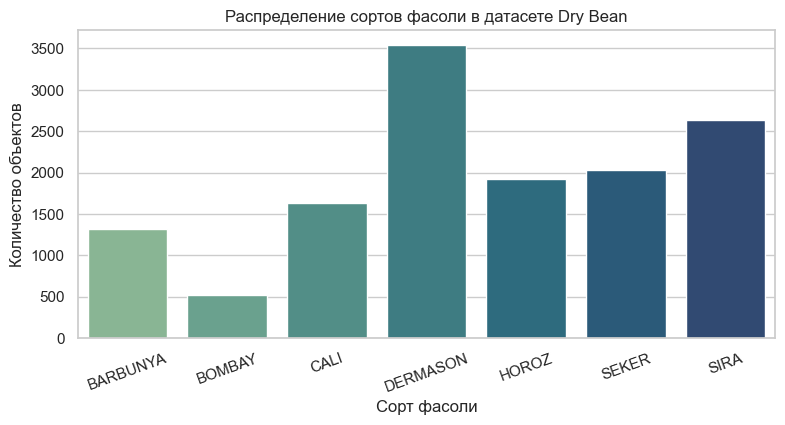

In [3]:
print("Информация о датасете:")
df.info()

print("\nСтатистическое описание числовых признаков:")
display(df.describe().round(3))

print("\nКоличество пропусков по столбцам:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nРаспределение исходных сортов фасоли:")
class_counts = df["Class"].value_counts().sort_index().to_frame("count")
display(class_counts)

plt.figure(figsize=(9, 4))
sns.countplot(data=df, x="Class", order=sorted(df["Class"].unique()), palette="crest")
plt.title("Распределение сортов фасоли в датасете Dry Bean")
plt.xlabel("Сорт фасоли")
plt.ylabel("Количество объектов")
plt.xticks(rotation=20)
plt.show()
        


### 4. Блок с предварительной обработкой датасета

Так как метод `K-Means` основан на евклидовом расстоянии, масштаб признаков существенно влияет на результат кластеризации. Поэтому перед обучением из набора удаляется столбец `Class`, после чего все числовые признаки стандартизируются. Дополнительно вычисляются две главные компоненты (`PCA`) для дальнейшей наглядной визуализации кластеров на плоскости.
        


In [4]:
X = df.drop(columns=["Class"])
reference_labels = df["Class"]

print(f"Матрица признаков: {X.shape}")
print(f"Количество уникальных сортов в исходных метках: {reference_labels.nunique()}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("Доля объяснённой дисперсии первых двух компонент:")
print(np.round(pca.explained_variance_ratio_, 4))
        


Матрица признаков: (13611, 16)
Количество уникальных сортов в исходных метках: 7
Доля объяснённой дисперсии первых двух компонент:
[0.5547 0.2643]


### 5. Блок с тепловой картой

Тепловая карта отражает корреляции между признаками формы и размера фасоли. Для удобства отображения показываются десять признаков, которые сильнее всего связаны с площадью зерна `Area`, так как именно она является одним из базовых геометрических параметров объекта.
        


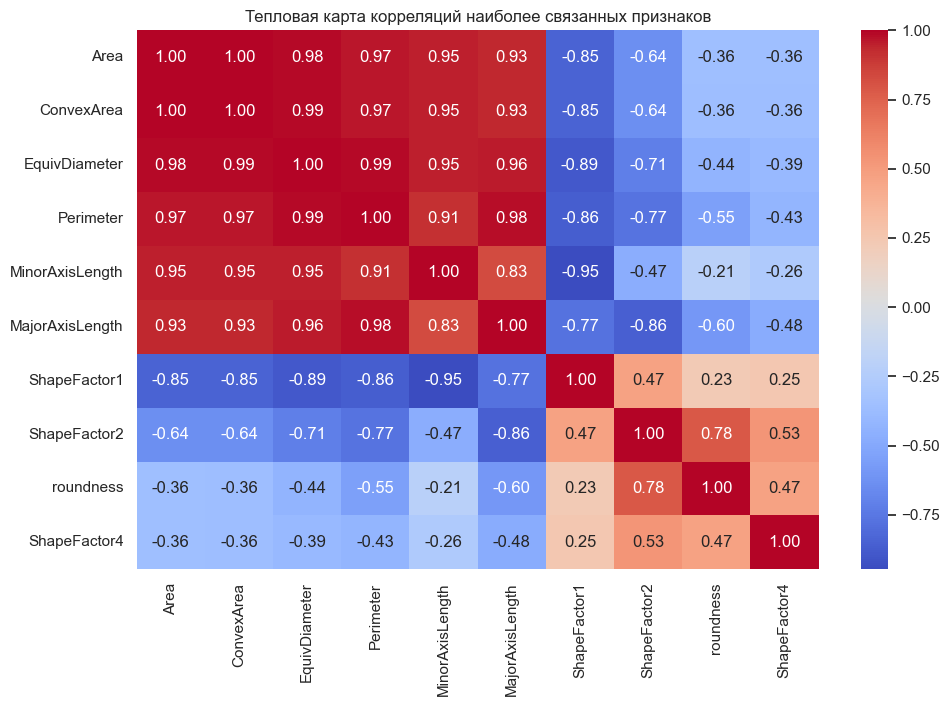

In [5]:
corr_matrix = X.corr(numeric_only=True)
top_corr_features = (
    corr_matrix["Area"]
    .drop("Area")
    .abs()
    .sort_values(ascending=False)
    .head(9)
    .index
    .tolist()
)
heatmap_features = ["Area"] + top_corr_features

plt.figure(figsize=(11, 7))
sns.heatmap(
    corr_matrix.loc[heatmap_features, heatmap_features],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
)
plt.title("Тепловая карта корреляций наиболее связанных признаков")
plt.show()
        


Area, ConvexArea, EquivDiameter, Perimeter, MinorAxisLength, MajorAxisLength очень сильно положительно коррелируют друг с другом:
значения в районе 0.93–1.00.

### 6. Блок с обучением модели

Сначала исследуется зависимость качества кластеризации от количества кластеров `k` в диапазоне от 2 до 10. Для этого рассчитываются две ключевые характеристики: `inertia` для метода локтя и `silhouette score` для оценки отделимости кластеров. После этого для сравнения алгоритмов `K-Means` и `K-Means++` фиксируется значение `k = 7`, поскольку в исходном наборе представлены семь сортов фасоли.
        


In [6]:
k_values = list(range(2, 11))
inertia_values = []
silhouette_values = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=RANDOM_STATE,
    )
    cluster_labels = model.fit_predict(X_scaled)
    inertia_values.append(model.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, cluster_labels))

evaluation_df = pd.DataFrame(
    {
        "k": k_values,
        "Inertia": np.round(inertia_values, 2),
        "Silhouette": np.round(silhouette_values, 4),
    }
)

display(evaluation_df)
print(f"Лучшее значение silhouette score в исследуемом диапазоне: k = {evaluation_df.loc[evaluation_df['Silhouette'].idxmax(), 'k']}")


,k,Inertia,Silhouette
0,2,129900.03,0.3967
1,3,94741.99,0.4047
2,4,76474.31,0.3416
3,5,61893.64,0.3569
4,6,55050.07,0.3602
5,7,48811.96,0.3094
6,8,45241.73,0.3031
7,9,41975.59,0.3033
8,10,39810.69,0.2661


Лучшее значение silhouette score в исследуемом диапазоне: k = 3


In [7]:
k_final = 7

kmeans_random = KMeans(
    n_clusters=k_final,
    init="random",
    n_init=1,
    random_state=RANDOM_STATE,
)
kmeans_plus = KMeans(
    n_clusters=k_final,
    init="k-means++",
    n_init=1,
    random_state=RANDOM_STATE,
)

clusters_random = kmeans_random.fit_predict(X_scaled)
clusters_plus = kmeans_plus.fit_predict(X_scaled)

comparison_metrics = pd.DataFrame(
    {
        "Модель": ["K-Means (random init)", "K-Means++"],
        "Inertia": [kmeans_random.inertia_, kmeans_plus.inertia_],
        "Silhouette": [
            silhouette_score(X_scaled, clusters_random),
            silhouette_score(X_scaled, clusters_plus),
        ],
        "Adjusted Rand Index": [
            adjusted_rand_score(reference_labels, clusters_random),
            adjusted_rand_score(reference_labels, clusters_plus),
        ],
    }
)

comparison_metrics["Inertia"] = comparison_metrics["Inertia"].round(2)
comparison_metrics["Silhouette"] = comparison_metrics["Silhouette"].round(4)
comparison_metrics["Adjusted Rand Index"] = comparison_metrics["Adjusted Rand Index"].round(4)

display(comparison_metrics)
        


,Модель,Inertia,Silhouette,Adjusted Rand Index
0,K-Means (random init),53289.29,0.2799,0.6151
1,K-Means++,48811.96,0.3094,0.6687


### 7. Блок с прогнозами модели

В задаче кластеризации под прогнозом понимается номер кластера, присвоенный каждому объекту. Ниже показаны примеры кластерных меток, полученных двумя вариантами алгоритма, а также исходный сорт фасоли для ориентировочного сравнения с реальной структурой данных.
        


In [8]:
cluster_assignment = X.reset_index(drop=True).copy()
cluster_assignment["Исходный сорт"] = reference_labels.reset_index(drop=True)
cluster_assignment["Кластер K-Means"] = clusters_random
cluster_assignment["Кластер K-Means++"] = clusters_plus

display(cluster_assignment.head(15))
        


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Исходный сорт,Кластер K-Means,Кластер K-Means++
0,28395.0,610.291,208.178117,173.888747,1.197191,0.549812,28715.0,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER,5,2
1,28734.0,638.018,200.524796,182.734419,1.097356,0.411785,29172.0,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER,5,2
2,29380.0,624.110,212.826130,175.931143,1.209713,0.562727,29690.0,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER,5,2
3,30008.0,645.884,210.557999,182.516516,1.153638,0.498616,30724.0,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER,5,2
4,30140.0,620.134,201.847882,190.279279,1.060798,0.333680,30417.0,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER,5,2
5,30279.0,634.927,212.560556,181.510182,1.171067,0.520401,30600.0,196.347702,0.775688,0.989510,0.943852,0.923726,0.007020,0.003153,0.853270,0.999236,SEKER,5,2
6,30477.0,670.033,211.050155,184.039050,1.146768,0.489478,30970.0,196.988633,0.762402,0.984081,0.853080,0.933374,0.006925,0.003242,0.871186,0.999049,SEKER,5,2
7,30519.0,629.727,212.996755,182.737204,1.165591,0.513760,30847.0,197.124320,0.770682,0.989367,0.967109,0.925480,0.006979,0.003158,0.856514,0.998345,SEKER,5,2
8,30685.0,635.681,213.534145,183.157146,1.165852,0.514081,31044.0,197.659696,0.771561,0.988436,0.954240,0.925658,0.006959,0.003152,0.856844,0.998953,SEKER,5,2
9,30834.0,631.934,217.227813,180.897469,1.200834,0.553642,31120.0,198.139012,0.783683,0.990810,0.970278,0.912125,0.007045,0.003008,0.831973,0.999061,SEKER,5,2


### 8. Блок с графиками выходных результатов

В итоговом блоке строятся основные визуализации для анализа кластеризации: график метода локтя, график силуэта, столбчатое сравнение метрик двух алгоритмов и отображение кластеров `K-Means++` на плоскости первых двух главных компонент.
        


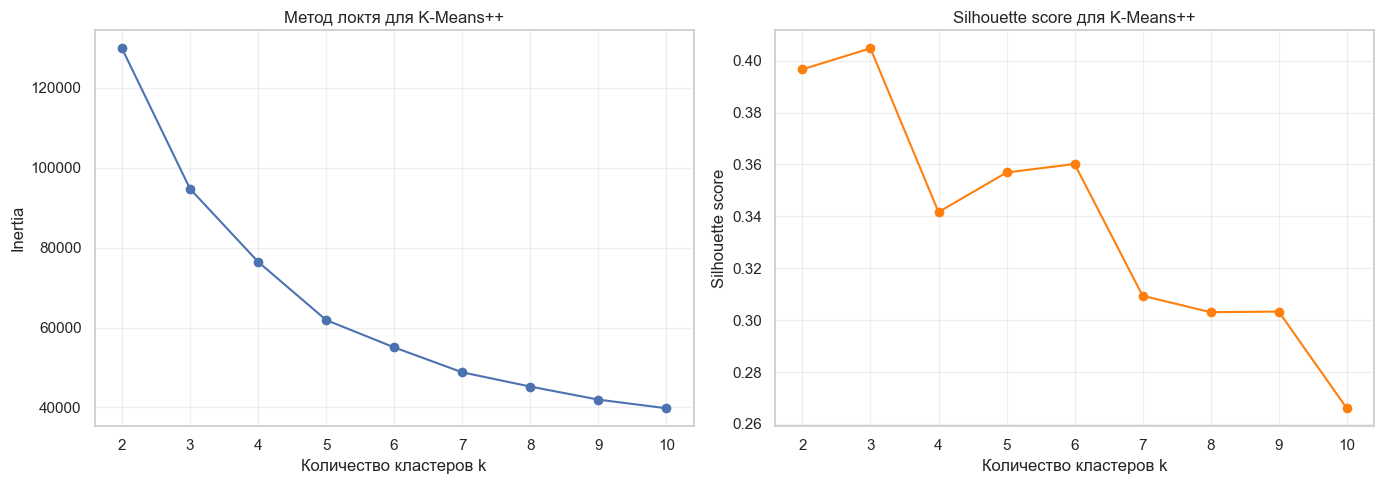

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, inertia_values, marker="o")
axes[0].set_title("Метод локтя для K-Means++")
axes[0].set_xlabel("Количество кластеров k")
axes[0].set_ylabel("Inertia")
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_values, silhouette_values, marker="o", color="tab:orange")
axes[1].set_title("Silhouette score для K-Means++")
axes[1].set_xlabel("Количество кластеров k")
axes[1].set_ylabel("Silhouette score")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
        


По графику метода локтя видно, что наиболее заметное снижение inertia наблюдается до k = 5–6, после чего эффект от увеличения числа кластеров уменьшается. По графику silhouette score наилучшее качество кластеризации достигается при k = 3, однако для дальнейшего анализа было выбрано k = 7, так как в исходном датасете присутствует семь сортов фасоли. Сравнение моделей показало, что K-Means++ превосходит обычный K-Means: при той же настройке числа кластеров он обеспечивает более высокий silhouette score и ARI, а также меньшую inertia. Визуализация в пространстве двух главных компонент подтверждает наличие выраженной кластерной структуры, хотя часть групп частично пересекается.


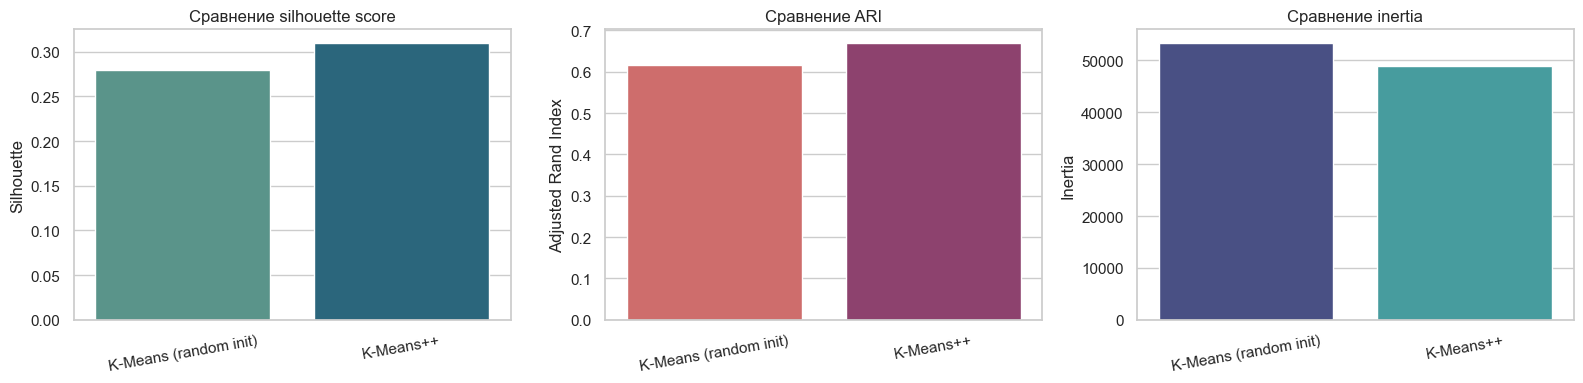

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=comparison_metrics, x="Модель", y="Silhouette", ax=axes[0], palette="crest")
axes[0].set_title("Сравнение silhouette score")
axes[0].set_xlabel("")
axes[0].set_ylabel("Silhouette")
axes[0].tick_params(axis="x", rotation=10)

sns.barplot(data=comparison_metrics, x="Модель", y="Adjusted Rand Index", ax=axes[1], palette="flare")
axes[1].set_title("Сравнение ARI")
axes[1].set_xlabel("")
axes[1].set_ylabel("Adjusted Rand Index")
axes[1].tick_params(axis="x", rotation=10)

sns.barplot(data=comparison_metrics, x="Модель", y="Inertia", ax=axes[2], palette="mako")
axes[2].set_title("Сравнение inertia")
axes[2].set_xlabel("")
axes[2].set_ylabel("Inertia")
axes[2].tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.show()
        


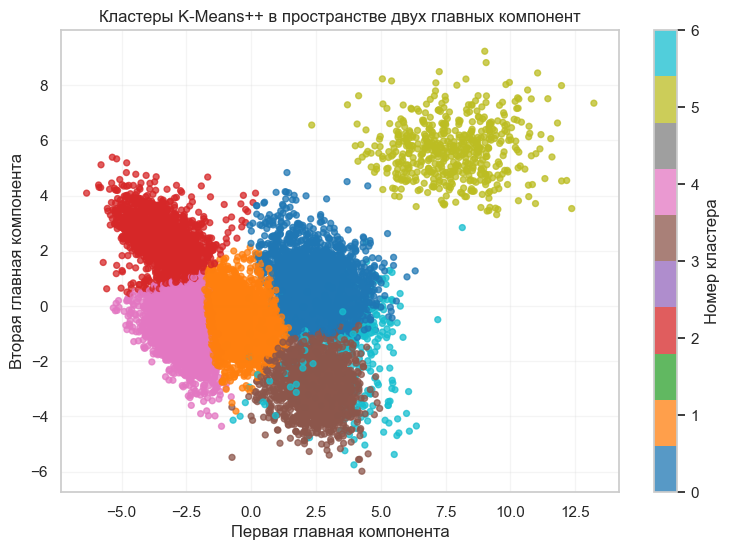

In [11]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_plus,
    cmap="tab10",
    s=18,
    alpha=0.75,
)
plt.title("Кластеры K-Means++ в пространстве двух главных компонент")
plt.xlabel("Первая главная компонента")
plt.ylabel("Вторая главная компонента")
plt.grid(True, alpha=0.2)
plt.colorbar(scatter, label="Номер кластера")
plt.show()
        


**Вывод:** на датасете `Dry Bean` оба алгоритма находят осмысленную кластерную структуру, однако `K-Means++` при одинаковом числе кластеров инициализирует центры удачнее и обычно показывает более низкую `inertia` и лучшие показатели качества. Метод локтя и график силуэта позволяют обосновать выбор числа кластеров, а визуализация в пространстве главных компонент делает структуру найденных групп более наглядной.
        
